In [1]:
# cuda visible 
import os 
os.environ['CUDA_VISIBLE_DEVICES'] = "1"

import torch.backends.cudnn as cudnn
cudnn.benchmark = True

In [2]:
import os 
import torch 
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torch.optim import Adam
from tqdm import tqdm
import matplotlib.pyplot as plt


from torch.utils.tensorboard import SummaryWriter
import torchvision.utils as vutils

from CityScapes import CityscapesDataset

from DCGAN.discriminator import Discriminator
from DCGAN.encoder import Encoder
from DCGAN.reconstruction_generator import ReconstructionGenerator
from DCGAN.segmentation_generator import SegmentationGenerator
from file_management import get_version_folder, save_config, load_config
from DCGAN.loss_functions import GradientPenaltyLoss, WeightedMSELoss, DriftLoss


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
scale_for_display = lambda x: torch.clamp((x + 1.0) / 2.0, 0.0, 1.0)


In [3]:
load_run = None
config_name = 'config.yaml'

In [4]:
if load_run:
    config_path = os.path.join(load_run,config_name)
    config = load_config(config_path)
    config['root_path'] = load_run
    
    index_folder = load_run
else:
    root = 'cache/dcgan'
    index_folder = get_version_folder(root)
    config = load_config(config_name)
    config['root_path'] =index_folder

    config_target_path = os.path.join(index_folder,config_name)
    save_config(config, config_target_path)




Config saved to cache/dcgan/3/config.yaml


In [5]:
channels = config['models']['channels']
z_shape = config['models']['z_shape']
z_dim = z_shape[0]
number_of_components = config['models']['number_of_components']

enc_block_depth = config['models']['enc']['block_depth']
enc_residual = config['models']['enc']['residual']
enc_use_norm = config['models']['enc']['use_norm']

gen_block_depth = config['models']['gen']['block_depth']
gen_residual = config['models']['gen']['residual']
gen_use_norm = config['models']['gen']['use_norm']
gen_vector_dim = config['models']['gen']['vector_dim']
gen_vectorizer_linear_layer_dim = config['models']['gen']['vectorizer_linear_layer_dim']
gen_degrees_of_freedom = config['models']['gen']['degrees_of_freedom']

seg_gen_block_depth = config['models']['segmentation_gen']['block_depth']
seg_gen_residual = config['models']['segmentation_gen']['residual']
seg_gen_use_norm = config['models']['segmentation_gen']['use_norm']

disc_block_depth = config['models']['disc']['block_depth']
disc_residual = config['models']['disc']['residual']
disc_use_norm = config['models']['disc']['use_norm']

batch_size = config['training']['batch_size']

enc_lr = config['training']['enc']['enc_lr']
enc_reconstruction_loss_weight = config['training']['enc']['enc_reconstruction_loss_weight']
enc_feature_loss_weight = config['training']['enc']['enc_feature_loss_weight']

gen_lr = config['training']['gen']['gen_lr']

seg_gen_lr=  config['training']['segmentation_gen']['seg_gen_lr']

n_critic = config['training']['disc']['n_critic']
disc_lr = config['training']['disc']['disc_lr']
disc_gp_loss_weight = config['training']['disc']['disc_gp_loss_weight']
disc_drift_loss_weight = config['training']['disc']['disc_drift_loss_weight']



save_itter = config["training"]["save_itter"]
samples_path = os.path.join(index_folder,'samples')
os.makedirs(samples_path,exist_ok=True)

enc_path = os.path.join(index_folder,'enc.pth')
gen_path = os.path.join(index_folder,'gen.pth')
disc_path = os.path.join(index_folder,'disc.pth')
seg_gen_path = os.path.join(index_folder,'seg_gen.pth')


tensorboard_path = os.path.join(index_folder, 'logs')
writer = SummaryWriter(log_dir=tensorboard_path)

In [6]:

enc = Encoder(channels=channels,
              block_depth=enc_block_depth,
              z_dim=z_dim,
              residual=enc_residual,
              img_channels=3,
              use_norm=enc_use_norm).to(device)

gen = ReconstructionGenerator(channels=channels,
                z_dim=z_dim,                
                number_of_components=number_of_components,
                vector_dim=gen_vector_dim,
                vectorizer_linear_layer_dim=gen_vectorizer_linear_layer_dim,
                degrees_of_freedom=gen_degrees_of_freedom,
                block_depth=enc_block_depth,
                residual=gen_residual,
                img_channels=3,
                use_norm=gen_use_norm).to(device)

seg_gen = SegmentationGenerator(channels=channels,
                z_dim=z_dim,                
                block_depth=enc_block_depth,
                residual=gen_residual,
                number_of_components=number_of_components,
                use_norm=gen_use_norm).to(device)

disc = Discriminator(channels=channels,
                      block_depth=disc_block_depth,
                      residual=disc_residual,
                      img_channels=3,
                      use_norm=disc_use_norm).to(device)



if load_run is not None:
    enc.load_state_dict(torch.load(enc_path))
    gen.load_state_dict(torch.load(gen_path))
    seg_gen.load_state_dict(torch.load(seg_gen_path))
    disc.load_state_dict(torch.load(disc_path))





enc_optim = Adam(enc.parameters(), lr=enc_lr, betas=(0.0, 0.9))
gen_optim = Adam(gen.parameters(), lr=gen_lr, betas=(0.0, 0.9))
seg_gen_optim = Adam(seg_gen.parameters(), lr=seg_gen_lr, betas=(0.0, 0.9))
disc_optim = Adam(disc.parameters(), lr=disc_lr, betas=(0.0, 0.9))

train_dataset = CityscapesDataset()
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


tensorboard_step = 0


In [7]:
def combine(recs, segs):
    """
    recs : (B, n, C, H, W)  – per-component RGB reconstructions
    segs : (B, n, H, W)     – per-component segmentation logits
    returns: (B, C, H, W)   – final composed image
    """
    # Soft mask for backward pass
    y_soft = F.softmax(segs, dim=1)                           # (B, n, H, W)
    
    # Hard one-hot mask for forward pass
    idx    = y_soft.argmax(dim=1, keepdim=True)               # (B, 1, H, W)
    y_hard = torch.zeros_like(y_soft).scatter_(1, idx, 1.0)   # (B, n, H, W)
    
    # STE: hard in forward, soft gradients in backward
    mask = y_hard - y_soft.detach() + y_soft                  # (B, n, H, W)

    mask = mask.unsqueeze(2)                                   # (B, n, 1, H, W)
    return (mask * recs).sum(dim=1)                            # (B, C, H, W)

In [8]:
train_iter = iter(train_loader)


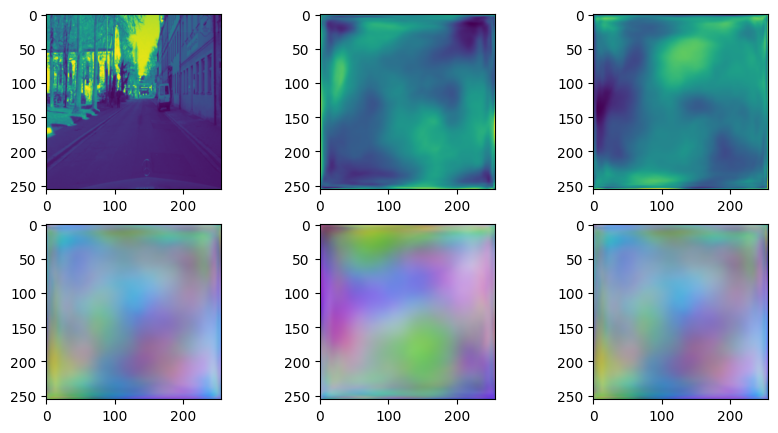

In [9]:
data ,_ = next(train_iter)
data = data.to(device)
with torch.no_grad():
    z = torch.randn(batch_size, *z_shape).to(device)
    reconstruction = gen(z)


    segmentation = seg_gen(z)
    num_classes = segmentation.shape[1]

    reconstructed_image = combine(reconstruction, segmentation)



components = reconstruction.shape[1]
fig,ax = plt.subplots(2,components+1,figsize=(10,5))
ax[0,0].imshow(data.cpu().numpy()[0,0])
for i in range(components):
    ax[0,i+1].imshow(segmentation.cpu().numpy()[0,i])


reconstructed_image = scale_for_display(reconstructed_image)
reconstruction = scale_for_display(reconstruction)
ax[1,0].imshow(reconstructed_image.cpu()[0].permute(1,2,0).numpy())
for i in range(components):
    ax[1,i+1].imshow(reconstruction[0,i].permute(1,2,0).cpu().numpy())
plt.show()


In [10]:
gp_loss_fn = GradientPenaltyLoss(weight=disc_gp_loss_weight)
reconstruction_loss_fn = WeightedMSELoss(weight=enc_reconstruction_loss_weight)
drift_loss_fn = DriftLoss(weight= disc_drift_loss_weight)

In [ ]:
epochs = 100

for epoch in range(0, epochs):
    loop = tqdm(range(len(train_loader)))
    loop.set_description(f"Epoch {epoch}/{epochs}")
    for i in loop:

        # ─── DISCRIMINATOR ───────────────────────────────────────────────
        for _ in range(n_critic):
            try:
                real, _ = next(data_iter)
            except:
                data_iter = iter(train_loader)
                real, _ = next(data_iter)
            current_batch_size = real.size(0)
            real = real.to(device)
            disc_optim.zero_grad()

            disc_real = disc(real)
            disc_real_loss = -torch.mean(disc_real)

            # fake from noise
            z_noise = torch.randn(current_batch_size, *z_shape).to(device)
            fake_recs = gen(z_noise)           # (B, n, C, H, W)
            fake_segs = seg_gen(z_noise)       # (B, n, 1, H, W) logits
            fake = combine(fake_recs, fake_segs)
            disc_fake = disc(fake.detach())
            disc_fake_loss = torch.mean(disc_fake)

            # reconstructed from encoded real
            with torch.no_grad():
                encoded_vector = enc(real)
                rec_recs = gen(encoded_vector)
                rec_segs = seg_gen(encoded_vector)
                reconstructed = combine(rec_recs, rec_segs)
            disc_reconstructed = disc(reconstructed)
            disc_reconstructed_loss = torch.mean(disc_reconstructed)

            disc_adv_loss = disc_real_loss + disc_fake_loss + disc_reconstructed_loss
            disc_gp_loss = (gp_loss_fn(disc, real, reconstructed.detach())
                          + gp_loss_fn(disc, real, fake.detach()))
            disc_drift_loss = drift_loss_fn(disc_real)

            disc_loss = disc_adv_loss + disc_gp_loss + disc_drift_loss
            disc_loss.backward()
            disc_optim.step()

        # ─── GENERATOR + SEG_GEN (noise branch) ─────────────────────────
        gen_optim.zero_grad()
        seg_gen_optim.zero_grad()

        z_noise = torch.randn(current_batch_size, *z_shape).to(device)
        fake_recs = gen(z_noise)
        fake_segs = seg_gen(z_noise)
        fake = combine(fake_recs, fake_segs)
        gen_adv_loss = -torch.mean(disc(fake))

        gen_adv_loss.backward()
        gen_optim.step()
        seg_gen_optim.step()

        # ─── ENCODER + GENERATOR + SEG_GEN (reconstruction branch) ──────
        gen_optim.zero_grad()
        seg_gen_optim.zero_grad()
        enc_optim.zero_grad()

        encoded_vector = enc(real)
        rec_recs = gen(encoded_vector)          # (B, n, C, H, W)
        rec_segs = seg_gen(encoded_vector)      # (B, n, 1, H, W) logits
        reconstructed = combine(rec_recs, rec_segs)

        disc_reconstructed, reconstructed_features = disc(reconstructed, return_features=True)
        with torch.no_grad():
            _, real_features = disc(real, return_features=True)

        enc_feature_loss = enc_feature_loss_weight * sum(
            F.l1_loss(f_enc, f_real.detach())
            for f_enc, f_real in zip(reconstructed_features, real_features)
        ) / len(reconstructed_features)

        enc_adv_loss = -torch.mean(disc_reconstructed)
        enc_reconstruction_loss = reconstruction_loss_fn(reconstructed, real)

        enc_loss = enc_adv_loss + enc_feature_loss + enc_reconstruction_loss
        enc_loss.backward()
        enc_optim.step()
        gen_optim.step()
        seg_gen_optim.step()

        # ─── LOGGING ─────────────────────────────────────────────────────
        writer.add_scalar('Discriminator_Losses/Adversarial', disc_adv_loss.item(), tensorboard_step)
        writer.add_scalar('Discriminator_Losses/GP',          disc_gp_loss.item(),  tensorboard_step)
        writer.add_scalar('Discriminator_Losses/Drift',       disc_drift_loss.item(), tensorboard_step)
        writer.add_scalar('Encoder_Losses/Adversarial',       enc_adv_loss.item(),  tensorboard_step)
        writer.add_scalar('Encoder_Losses/Reconstruction',    enc_reconstruction_loss.item(), tensorboard_step)
        writer.add_scalar('Encoder_Losses/Feature',           enc_feature_loss.item(), tensorboard_step)
        writer.add_scalar('Generator_Losses/Adversarial',     gen_adv_loss.item(),  tensorboard_step)
        tensorboard_step += 1

        loop.set_postfix(
            loss_disc=disc_loss.item(),
            loss_gen=gen_adv_loss.item(),
            enc_loss=enc_loss.item()
        )

        if (i + 1) % save_itter == 0:
            torch.save(enc.state_dict(),     enc_path)
            torch.save(gen.state_dict(),     gen_path)
            torch.save(seg_gen.state_dict(), seg_gen_path)
            torch.save(disc.state_dict(),    disc_path)

            epoch_root = f'epoch_{epoch}'
            os.makedirs(os.path.join(samples_path, epoch_root), exist_ok=True)

            with torch.no_grad():
                noise = torch.randn(current_batch_size, *z_shape).to(device)
                fake_recs = gen(noise)
                fake_segs = seg_gen(noise)
                fake = combine(fake_recs, fake_segs)

                encoded_vector = enc(real)
                rec_recs = gen(encoded_vector)
                rec_segs = seg_gen(encoded_vector)
                reconstructed = combine(rec_recs, rec_segs)

            fake         = scale_for_display(fake)
            reconstructed = scale_for_display(reconstructed)
            real_disp    = scale_for_display(real)

            imgs_to_plot = torch.cat([real_disp[:4], reconstructed[:4], fake[:4]], dim=0)
            grid = vutils.make_grid(imgs_to_plot, nrow=4)
            vutils.save_image(grid, os.path.join(samples_path, epoch_root, f'{i}.png'))

Epoch 0/100:   0%|          | 0/1250 [00:00<?, ?it/s]

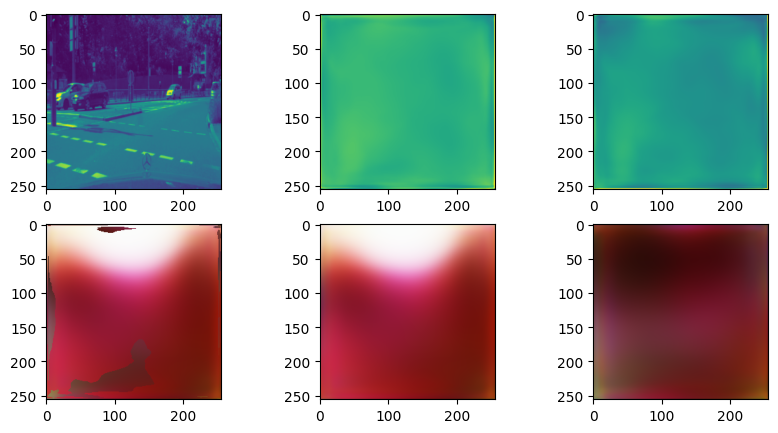

In [21]:
data ,_ = next(train_iter)
data = data.to(device)
with torch.no_grad():
    z = torch.randn(batch_size, *z_shape).to(device)
    reconstruction = gen(z)


    segmentation = seg_gen(z)
    num_classes = segmentation.shape[1]

    reconstructed_image = combine(reconstruction, segmentation)



components = reconstruction.shape[1]
segmentation = scale_for_display(segmentation)
fig,ax = plt.subplots(2,components+1,figsize=(10,5))
ax[0,0].imshow(data.cpu().numpy()[0,0])
for i in range(components):
    ax[0,i+1].imshow(segmentation.cpu().numpy()[0,i])


reconstructed_image = scale_for_display(reconstructed_image)
reconstruction = scale_for_display(reconstruction)
ax[1,0].imshow(reconstructed_image.cpu()[0].permute(1,2,0).numpy())
for i in range(components):
    ax[1,i+1].imshow(reconstruction[0,i].permute(1,2,0).cpu().numpy())
plt.show()
# plt.imshow(target_mask.cpu()[0])
